# imports

In [1]:
import os 
import random
random.seed(24)
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load data

## Load SAR oil slick data

In [ ]:
## Read the slick shapefile/geojson with geopandas
gdf = gpd.read_file('data/slicks.geojson')


# data preprocessing
gdf.drop(columns={'OBJECTID', 'Shape_Area', 'length_m'},inplace=True,errors='ignore')
gdf.rename(columns={'current_direction': 'current_direction_deg', 'wind_direction': 'wind_direction_deg', 'Shape_Length': 'perimeter_m','centerline_length_m':'length_m'}, inplace=True)
gdf.rename(columns={'date':'img_id'},inplace=True)
gdf['a1'] = 1
gdf['sensor'] = gdf['img_id'].str.split('_').str[0]
gdf['m'] = gdf['img_id'].str.split('2025').str[1].str.strip('_').str[:2]
gdf['d'] = gdf['img_id'].str.split('2025').str[1].str.strip('_').str[2:].str.strip('_').str[:2]
gdf['h'] = gdf['img_id'].str.split('.tif').str[0].str[-6:-4]
gdf.loc[gdf['h']=='21','h'] = '22'
gdf.loc[gdf['h']=='09','h'] = '10'
gdf['img_datetime'] = pd.to_datetime('2025-' + gdf['m'] + '-' + gdf['d'] + ' ' + gdf['h'], format='%Y-%m-%d %H', utc=True)

# reproject to UTM 20N
print(gdf.crs.name)
gdf = gdf.to_crs(epsg=32620)
print('reprojected to:' ,gdf.crs.name)

# show gdf structure
gdf.head()

WGS 84
reprojected to: WGS 84 / UTM zone 20N


,OBJECTID_1,img_id,wind_spd_km_h,a1,current_direction_deg,wind_direction_deg,area_km2,length_m,area_m2,perimeter_m,geometry,sensor,m,d,h,img_datetime
0,25.0,RCM_20250729_102241.tif,15.0,1,105.0,174.0,0.297548,1602.93420,2.975477e+05,3549.447933,"POLYGON ((664394.696 5345043.723, 664474.432 5...",RCM,07,29,10,2025-07-29 10:00:00+00:00
1,26.0,RCM_20250730_095919.tif,15.0,1,316.0,357.0,6.081574,19329.51560,6.081574e+06,40418.802716,"POLYGON ((664569.295 5345362.567, 664942.431 5...",RCM,07,30,10,2025-07-30 10:00:00+00:00
2,27.0,S1_2025_07_30_215536.tif,10.0,1,200.0,210.0,1.354654,5898.47607,1.354654e+06,12182.323581,"POLYGON ((664010.405 5345762.857, 664178.684 5...",S1,07,30,22,2025-07-30 22:00:00+00:00
3,28.0,RCM_20250731_100704.tif,10.0,1,116.0,225.0,6.092799,19051.91800,6.092799e+06,40149.066653,"POLYGON ((664507.807 5344905.547, 664582.001 5...",RCM,07,31,10,2025-07-31 10:00:00+00:00
4,29.0,S1_2025_08_06_214725.tif,13.0,1,104.0,314.0,1.792761,7183.97021,1.792761e+06,15720.228676,"POLYGON ((664419.054 5345510.231, 664355.932 5...",S1,08,06,22,2025-08-06 22:00:00+00:00


## Load IML-10 buoy data

In [ ]:
# Load and preprocess IML-10 buoy data

df_current = pd.read_csv('data/current_speed_pred/2025_preds.csv')
df_current['date'] = pd.to_datetime(df_current['date'].str.strip('[UTC]'), format='ISO8601', utc=True)
df_current['wind_spd_m_s'] = df_current['Vitesse du vent'] *1000/3600 #km/h to m/s
df_current.rename(columns={'current_speed_m_s':'current_spd_m_s'}, inplace=True)


df = pd.read_csv('data/wind_current_iml10.csv', encoding='ISO-8859-1')
df['date'] = pd.to_datetime(df['date'].str.strip('[UTC]'), format='ISO8601', utc=True)
df.drop(columns={'Station','Position (geoJSON)', 'Fournisseur','Profondeur','Eau - pH', 'Courant - Vitesse (6m)', 'Courant-Direction(6m)', 'PAR'}, inplace=True, errors='ignore')
df['wind_speed_m_s'] = df['Vitesse du vent'] *1000/3600 #km/h to m/s
df

,date,Temp. de l'eau,Salinité,Pression,Densité,Fluorescence,Période de vague,Hauteur de vague moy.,Hauteur de vague max.,Vitesse du vent,Rafales,Direction du vent,Temp. air,Humidité,Précipitation,CDOM,Courant - Vitesse (0m),Courant-Direction(0m),Eau - Rétrodiffusion,wind_speed_m_s
0,2025-07-25 20:00:00+00:00,15.33,30.83,100.659996,1022.70,0.5760,4.8,1.1,1.6,13.0,19.0,232.0,15.9,89.0,0.8,4.54,NaN,44.0,0.000775,3.611111
1,2025-07-25 20:30:00+00:00,15.36,30.79,100.659996,1022.66,0.5616,4.6,1.0,1.8,9.0,13.0,254.0,15.9,89.0,3.1,4.45,NaN,55.0,0.000766,2.500000
2,2025-07-25 21:00:00+00:00,14.89,30.63,100.620000,1022.63,0.5976,4.3,0.9,1.4,10.0,14.0,227.0,15.6,89.0,4.6,4.91,NaN,62.0,0.000827,2.777778
3,2025-07-25 21:30:00+00:00,14.56,30.39,100.620000,1022.51,0.6624,4.5,1.0,1.6,9.0,13.0,236.0,15.6,89.0,7.4,5.10,NaN,68.0,0.000893,2.500000
4,2025-07-25 22:00:00+00:00,14.76,30.47,100.640000,1022.54,0.5472,4.6,0.9,1.4,10.0,13.0,316.0,15.9,90.0,7.8,5.01,NaN,76.0,0.000829,2.777778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2025-09-26 17:30:00+00:00,14.56,31.11,99.580000,1023.07,NaN,5.5,2.6,4.0,36.0,49.0,284.0,15.4,86.0,36.3,NaN,NaN,94.0,NaN,10.000000
2996,2025-09-26 18:00:00+00:00,14.55,31.11,99.659996,1023.07,NaN,5.2,2.3,3.9,37.0,51.0,292.0,15.1,83.0,36.3,NaN,NaN,102.0,NaN,10.277778
2997,2025-09-26 18:30:00+00:00,14.59,31.12,99.670000,1023.07,NaN,5.6,2.3,4.0,41.0,54.0,300.0,14.9,83.0,36.3,NaN,NaN,106.0,NaN,11.388889
2998,2025-09-26 19:00:00+00:00,14.64,31.12,99.720000,1023.07,NaN,5.1,2.3,3.5,39.0,55.0,298.0,14.5,83.0,36.3,NaN,NaN,115.0,NaN,10.833333


## Load air pressure data (IML-10 in weeks before seep start)

In [ ]:
df_0607 = pd.read_csv('data/june_july.csv', encoding='ISO-8859-1')
# df2 =  pd.read_csv('data/export.csv', encoding='ISO-8859-1')
# df2 = df2.loc[:54]
# df = pd.concat([df2,df], ignore_index=True)
df_0607.drop(columns={'Station','Position (geoJSON)', 'Fournisseur','Profondeur','Eau - pH', 'Courant - Vitesse (6m)', 'Courant-Direction(6m)', 'PAR'}, inplace=True, errors='ignore')
df_0607['date'] = pd.to_datetime(df_0607['date'].str.strip('[UTC]'), format='ISO8601', utc=True)
df_0607.tail()

## Load tidal data

In [8]:
tides_df = pd.read_csv('data/tides/wlo_665.csv')
tides_df['date'] = pd.to_datetime(tides_df['date'], format='%Y/%m/%d %H:%M')
tides_df.rename(columns={'water_level_m':'wlo_pab'},inplace=True)

name_dict = {
    663: 'grand_bay',
    665: 'pab',
    2725: 'crabbes_river',
    1970: 'cap_aux_meules',
    1986: 'old_harry',
    2415: 'baie_du_renard'
}

for wlp in os.listdir('data/tides'):
    if not wlp.startswith('wlp') or not wlp.endswith('.csv'):
        continue
    station_nmr = wlp.strip('wlp_').strip('.csv')
    print(station_nmr)
    station_name = name_dict[int(station_nmr)]
    print(station_name)
    wlp_df = pd.read_csv(f'data/tides/{wlp}')
    tides_df[f'wlp_{station_name}'] = wlp_df['water_level_m']

tides_df

1970
cap_aux_meules
1986
old_harry
2415
baie_du_renard
2725
crabbes_river
663
grand_bay
665
pab


,date,wlo_pab,wlp_cap_aux_meules,wlp_old_harry,wlp_baie_du_renard,wlp_crabbes_river,wlp_grand_bay,wlp_pab
0,2025-06-01 00:30:00,1.980,0.570,0.528,0.378,0.713,1.088,0.820
1,2025-06-01 01:30:00,2.031,0.706,0.717,0.601,1.016,1.404,1.040
2,2025-06-01 02:30:00,1.933,0.874,0.840,0.907,1.314,1.659,1.299
3,2025-06-01 03:30:00,1.783,1.021,0.897,1.215,1.553,1.817,1.544
4,2025-06-01 04:30:00,1.544,1.131,0.909,1.434,1.684,1.844,1.718
...,...,...,...,...,...,...,...,...
3689,2025-11-01 19:30:00,1.735,0.844,0.686,0.576,0.969,1.175,0.977
3690,2025-11-01 20:30:00,1.687,0.914,0.743,0.679,1.093,1.332,1.144
3691,2025-11-01 21:30:00,1.517,1.007,0.800,0.823,1.231,1.454,1.339
3692,2025-11-01 22:30:00,1.318,1.114,0.861,0.970,1.352,1.525,1.513


In [2]:
#preprocess
tides_qc = pd.read_csv('data/tides/tide_gasp.csv')
tides_nwf = pd.read_csv('data/tides/tide_newfoundland.csv')
tides_brion = pd.read_csv('data/tides/tides_brion.csv', usecols=[0, 1])
tides_brion = tides_brion[68:1436]
tides_qc['date'] = pd.to_datetime(tides_qc['date'], format='%Y/%m/%d %H:%M')
tides_qc = tides_qc[:1367]
tides_nwf = tides_nwf[:-1]
tides_nwf['date'] = pd.to_datetime(tides_nwf['date'], format='%Y/%m/%d %H:%M')
tides_brion['date'] = pd.to_datetime(tides_brion['date'], format='%Y/%m/%d %H:%M')
tides_brion['date'] = tides_brion['date'].apply(lambda d: d.replace(year=2025))

tides_nwf

,Unnamed: 0,date,water_level_m
0,0,2025-07-25 00:00:00,1.841
1,1,2025-07-25 01:00:00,1.947
2,2,2025-07-25 02:00:00,1.903
3,3,2025-07-25 03:00:00,1.744
4,4,2025-07-25 04:00:00,1.481
...,...,...,...
1692,1692,2025-09-26 15:00:00,2.040
1693,1693,2025-09-26 16:00:00,2.058
1694,1694,2025-09-26 17:00:00,1.958
1695,1695,2025-09-26 18:00:00,1.758


Check tidal period (should be around 12 hours)

In [11]:
from scipy.signal import argrelextrema
# Find local minima (low tides)
if 'date' in tides_df.columns:
    tides_df['date'] = pd.to_datetime(tides_df['date'], utc=True)
    tides_df.set_index('date', inplace=True)

for col in tides_df.columns:
    water_levels = tides_df[col].values
    min_indices = argrelextrema(water_levels, np.less, order=6)[0]  # order=6 can be adjusted

    # Get corresponding timestamps
    low_tide_times = tides_df.index[min_indices]

    # Compute time differences between consecutive low tides
    tidal_periods = np.diff(low_tide_times)  # returns array of timedelta64

    # Convert to hours
    tidal_periods_hours = [td.total_seconds() / 3600 for td in tidal_periods]

    # Calculate average tidal period
    average_period_hours = np.mean(tidal_periods_hours)

    print(f"Average tidal period {col}: {average_period_hours} hours")


Average tidal period wlo_pab: 12.58904109589041 hours
Average tidal period wlp_cap_aux_meules: 13.93560606060606 hours
Average tidal period wlp_old_harry: 13.992395437262358 hours
Average tidal period wlp_baie_du_renard: 12.679310344827586 hours
Average tidal period wlp_crabbes_river: 12.549488054607508 hours
Average tidal period wlp_grand_bay: 12.556313993174061 hours
Average tidal period wlp_pab: 12.595890410958905 hours


plot all nearby tidal stations. The neap-spring cycles should be coordinated

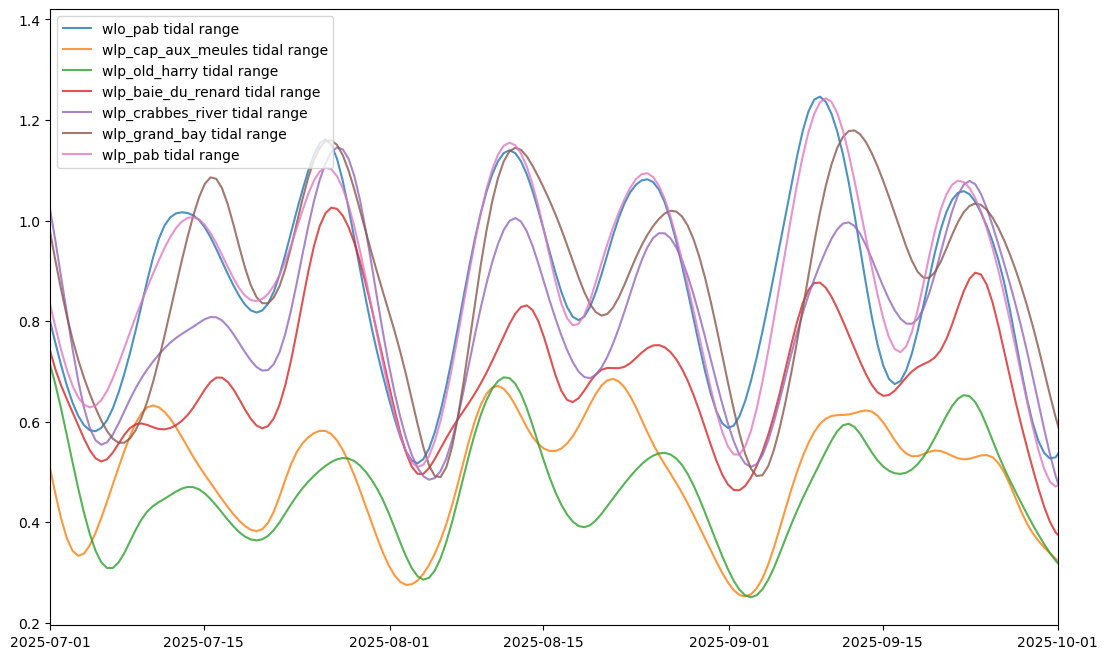

In [12]:
from scipy.ndimage import gaussian_filter1d
if 'date' in tides_df.columns:
    tides_df['date'] = pd.to_datetime(tides_df['date'], utc=True)
    tides_df.set_index('date', inplace=True)

    
tides_smooth_df = pd.DataFrame({})

plt.figure(figsize=(13,8))
for col in tides_df.columns:
    min_12h = tides_df[col].resample('12.6h').min() 
    max_12h = tides_df[col].resample('12.6h').max()
    range = max_12h - min_12h  # tidal range
    # Apply Gaussian smoothing
    smooth_min = gaussian_filter1d(min_12h.values, sigma=2.4)
    smooth_max = gaussian_filter1d(max_12h.values, sigma=2.4)
    smooth_range = gaussian_filter1d(range.values, sigma=2.4) # tidal range
    # Plot smoothed min and max lines
    # plt.plot(min_12h.index, smooth_min,alpha=0.8,label=f'{col}_min')
    # plt.plot(max_12h.index, smooth_max,alpha=0.8,label=f'{col}_max')
    plt.plot(max_12h.index, smooth_range,alpha=0.8,label=f'{col} tidal range')
    if not 'date' in tides_smooth_df.columns:
        tides_smooth_df['date'] = min_12h.index
    if col.startswith('wlo'):
        tides_smooth_df['wlo_min_12h'] = smooth_min
        tides_smooth_df['wlo_max_12h'] = smooth_max
        tides_smooth_df['wlo_range_12h'] = smooth_range  
    

plt.xlim(pd.to_datetime('2025-07-01'),pd.to_datetime('2025-10-01'))

plt.legend()
plt.show()

Plot neap-spring cycles from the closest station (Pointe-aux-basques)

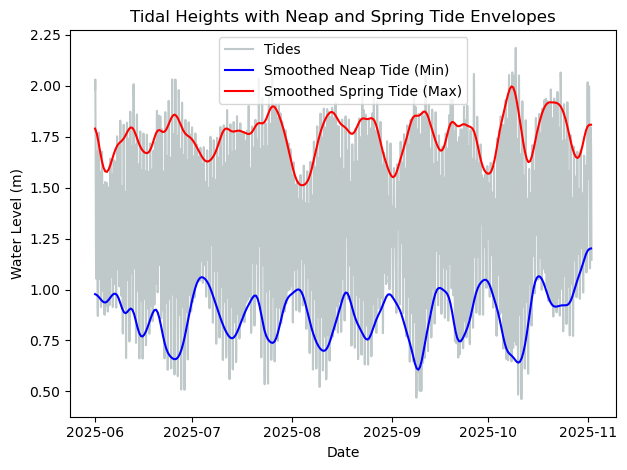

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Plot original data
# fig, plt = plt.subplots(figsize=(12, 6))
plt.plot(tides_df.index, tides_df['wlo_pab'], label='Tides', color='darkslategrey', alpha=0.3)

# Plot smoothed min and max lines
plt.plot(tides_smooth_df['date'], tides_smooth_df['wlo_min_12h'], label='Smoothed Neap Tide (Min)', color='blue')
plt.plot(tides_smooth_df['date'], tides_smooth_df['wlo_max_12h'], label='Smoothed Spring Tide (Max)', color='red')

# plt.xlim(pd.to_datetime('2025-07-01'),pd.to_datetime('2025-09-01'))

# Add labels and legend
plt.title('Tidal Heights with Neap and Spring Tide Envelopes')
plt.xlabel('Date')
plt.ylabel('Water Level (m)')
plt.legend()
plt.tight_layout()
plt.show()


# Wind and currents

## 10m wind spd profile 

from Hsu et al. 1994


In [18]:
#from Hsu et al. 1994
def wind_profile_conversion(U_0_5, z_0_5=0.5, z_r=10):
    """
    Convert wind speed at height z_0_5 to wind speed at height z_r using the power law profile.

    Parameters:
    - U_0_5: Wind speed at 0.5m (input)
    - z_0_5: Height at which U_0_5 is measured (default is 0.5m)
    - z_r: Height at which wind speed is being calculated (default is 10m)
    
    Returns:
    - U_r: Wind speed at height z_r
    """
    U_r = U_0_5 * (z_r / z_0_5) ** 0.11
    return U_r

# apply conversion
df_current['wind_spd_m_s_10m'] = df_current['wind_spd_m_s'].apply(wind_profile_conversion)
df['wind_speed_m_s_10m'] = df['wind_speed_m_s'].apply(wind_profile_conversion)

## Choose method to calculate V_s

Oil slick drift equation with Stokes drift (e.g. Breivik papers)

### with breivik stokes drift

In [ ]:
# Constants
alpha = 0.02  # wind drift factor
beta = 1     # current drift factor
g = 9.81       # gravity


# Convert angles to radians
theta_wind_rad = np.radians(df_current['Direction du vent'].values)
theta_current_rad = np.radians(df_current['Courant-Direction(0m)'].values)
theta_wave_rad = theta_wind_rad  # assuming in direction of wind (Sutherland 2020)

# Speeds
V_w = df_current['wind_spd_m_s_10m'].values
V_w0 = df_current['wind_spd_m_s'].values
V_c = df_current['current_spd_m_s'].values

# Wave parameters
H_s = df_current['Hauteur de vague moy.'].values          # significant wave height (m)
T_p = df_current['Période de vague'].values          # peak period (s)

# Compute wind deflection angle
theta_deg = 40 - 8 * np.sqrt(V_w0)  # Wang et al.
theta_rad = np.radians(theta_deg) 

# Rotation matrices
cos_theta = np.cos(theta_rad)
sin_theta = np.sin(theta_rad)

# Wind vectors
V_w_vec = np.vstack((V_w * np.cos(theta_wind_rad),
                        V_w * np.sin(theta_wind_rad)))

# Current vectors
V_c_vec = np.vstack((V_c * np.cos(theta_current_rad),
                        V_c * np.sin(theta_current_rad)))

# Rotate wind vectors
V_w_rotated = np.vstack((cos_theta * V_w_vec[0] - sin_theta * V_w_vec[1],
                            sin_theta * V_w_vec[0] + cos_theta * V_w_vec[1]))

# Stokes drift magnitude
V_stokes = (np.pi**3 * H_s**2) / (g * T_p**3)

# Stokes drift vector
V_stokes_vec = np.vstack((V_stokes * np.cos(theta_wave_rad),
                            V_stokes * np.sin(theta_wave_rad)))

# Combine all components
V_s_vec = alpha * V_w_rotated + beta * V_c_vec + V_stokes_vec

# Magnitude
V_s = np.maximum(np.linalg.norm(V_s_vec, axis=0), V_c+V_stokes) 

# Add to DataFrame
df_current['V_s'] = V_s


## ADAPTIVE AGE 

Calculate a BASE slick age using the average of 6.5 hrs (Daneshgar 2017; Meurer 2022)

In [27]:
# Convert to UTC-aware datetime
gdf['img_datetime'] = pd.to_datetime(gdf['img_datetime'], utc=True)

if 'date' in df_current.columns:
    df_current['date'] = pd.to_datetime(df_current['date'], utc=True)
else:
    df_current.reset_index(inplace=True)

# Set df_current index to datetime for efficient filtering
df_current.set_index('date', inplace=True)

# Function to compute circular mean in degrees
def circular_mean(rad_angles):
    # Calculate circular mean using the arctan2 method
    return np.rad2deg(np.arctan2(
        np.mean(np.sin(rad_angles)),
        np.mean(np.cos(rad_angles))
    )) % 360

# Main function to compute rolling medians
def compute_rolling_means(timestamp):
    start_time = timestamp - pd.Timedelta(hours=6.5) # meurer avg
    relevant_data = df_current.loc[start_time:timestamp]

    current_speed = relevant_data['current_spd_m_s'].replace(0, pd.NA)
    wind_speed = relevant_data['wind_spd_m_s_10m'].replace(0, pd.NA)
    current_dir = relevant_data['Courant-Direction(0m)'].replace(0, pd.NA)
    wind_dir = relevant_data['Direction du vent'].replace(0, pd.NA)
    Vs = relevant_data['V_s'].mask(relevant_data['V_s'] <= 0, pd.NA)
    
    # Drop NaN values to ensure we're only working with valid data
    current_dir = pd.to_numeric(current_dir.dropna())
    wind_dir = pd.to_numeric(wind_dir.dropna())

    # Convert directions to radians
    current_dir_rad = np.deg2rad(current_dir.values)
    wind_dir_rad = np.deg2rad(wind_dir.values)

    return pd.Series({
        'avg_current_spd_m_s': np.nanmean(current_speed),
        'avg_wind_spd_m_s': np.nanmean(wind_speed),
        'avg_current_dir': circular_mean(current_dir_rad),
        'avg_wind_dir': circular_mean(wind_dir_rad),
        'avg_Vs': np.nanmean(Vs),
    })


# Apply the function to your GeoDataFrame
averages = gdf['img_datetime'].apply(compute_rolling_means)


# Add results to gdf
gdf = pd.concat([gdf, averages], axis=1).reset_index(drop=True)

C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\2308261349.py:40: RuntimeWarning: Mean of empty slice
  'avg_current_spd_m_s': np.nanmean(current_speed),
C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\2308261349.py:41: RuntimeWarning: Mean of empty slice
  'avg_wind_spd_m_s': np.nanmean(wind_speed),
c:\Users\juvad3723\AppData\Local\miniforge3\envs\geo-env\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\juvad3723\AppData\Local\miniforge3\envs\geo-env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\2308261349.py:44: RuntimeWarning: Mean of empty slice
  'avg_Vs': np.nanmean(Vs),


In [ ]:
# calculate slick age (slick residence time)
gdf['slick_age_s'] = gdf['length_m'] / gdf['avg_Vs']

gdf['slick_age_h'] = gdf['slick_age_s'] / 3600 # s to hour

print('mean residence time (h):', gdf['slick_age_h'].mean())
gdf.head()

mean residence time (h): 8.310291373253655


,OBJECTID_1,img_id,wind_spd_km_h,a1,current_direction_deg,wind_direction_deg,area_km2,length_m,area_m2,perimeter_m,...,d,h,img_datetime,avg_current_spd_m_s,avg_wind_spd_m_s,avg_current_dir,avg_wind_dir,avg_Vs,slick_age_s,slick_age_h
0,25.0,RCM_20250729_102241.tif,15.0,1,105.0,174.0,0.297548,1602.93420,2.975477e+05,3549.447933,...,29,10,2025-07-29 10:00:00+00:00,0.229037,6.013665,63.270720,176.664302,0.244996,6542.690065,1.817414
1,26.0,RCM_20250730_095919.tif,15.0,1,316.0,357.0,6.081574,19329.51560,6.081574e+06,40418.802716,...,30,10,2025-07-30 10:00:00+00:00,0.253479,6.455035,281.136557,356.697525,0.303936,63597.262068,17.665906
2,27.0,S1_2025_07_30_215536.tif,10.0,1,200.0,210.0,1.354654,5898.47607,1.354654e+06,12182.323581,...,30,22,2025-07-30 22:00:00+00:00,0.230782,5.820566,147.424577,250.070586,0.271792,21702.158807,6.028377
3,28.0,RCM_20250731_100704.tif,10.0,1,116.0,225.0,6.092799,19051.91800,6.092799e+06,40149.066653,...,31,10,2025-07-31 10:00:00+00:00,0.177819,5.075754,101.941999,259.531823,0.185948,102458.374778,28.460660
4,29.0,S1_2025_08_06_214725.tif,13.0,1,104.0,314.0,1.792761,7183.97021,1.792761e+06,15720.228676,...,06,22,2025-08-06 22:00:00+00:00,0.178584,5.241268,92.957100,310.715841,0.190772,37657.322515,10.460367


RECALCULATE average conditions over temporary estimated age window (this yields not so much change but likely is more precise)

In [29]:
## With max wind speed clip

# Function to compute circular mean in degrees
def circular_mean(rad_angles):
    # Calculate circular mean using the arctan2 method
    return np.rad2deg(np.arctan2(
        np.mean(np.sin(rad_angles)),
        np.mean(np.cos(rad_angles))
    )) % 360

# Main function to compute rolling medians
def compute_temporal_averages(row):
    # Accessing slick_age_h from the row, which gives a custom time
    residence_time_h = row['slick_age_h']  # slick_age_h for this particular row + margin
    if residence_time_h == None or pd.isna(residence_time_h):
        residence_time_h = 0

    timestamp = row['img_datetime']  # Timestamp for this row

    # Calculate the start time based on the custom hours for this row
    start_time = timestamp - pd.Timedelta(hours=residence_time_h)
    
    # Retrieve relevant data based on start_time and timestamp
    relevant_data = df_current.loc[start_time:timestamp]

    ## FIX for that one timepoint with no buoy recordings within 2hrs
    if row['img_id'] == 'S1_2025_09_04_215536.tif':
        start_time = timestamp - pd.Timedelta(hours=3.5)
        end_time = timestamp + pd.Timedelta(hours=2)
        relevant_data = df_current.loc[start_time:end_time]

    # Replace 0s with NaNs to exclude them from stats
    current_speed = relevant_data['current_spd_m_s'].replace(0, pd.NA)
    wind_speed = relevant_data['wind_spd_m_s_10m'].replace(0, pd.NA)
    wind_speed0m = relevant_data['wind_spd_m_s'].replace(0, pd.NA)
    current_dir = relevant_data['Courant-Direction(0m)'].replace(0, pd.NA)
    wind_dir = relevant_data['Direction du vent'].replace(0, pd.NA)
    Vs = relevant_data['V_s'].mask(relevant_data['V_s'] <= 0, pd.NA)

    # Drop NaN values to ensure we're only working with valid data
    current_dir = pd.to_numeric(current_dir.dropna())
    wind_dir = pd.to_numeric(wind_dir.dropna())
    

    # Convert directions to radians
    current_dir_rad = np.deg2rad(current_dir.values)
    wind_dir_rad = np.deg2rad(wind_dir.values)

    return pd.Series({
        'avg_current_spd_m_s': np.nanmean(current_speed),
        'avg_wind_spd_m_s': np.nanmean(wind_speed),
        'avg_wind_spd_m_s_0m': np.nanmean(wind_speed0m),
        'avg_current_dir': circular_mean(current_dir_rad),
        'avg_wind_dir': circular_mean(wind_dir_rad),
        'avg_Vs': np.nanmean(Vs)
    })


# Apply the function
averages = gdf.apply(compute_temporal_averages, axis=1)

# Reassign values to existing columns in gdf
gdf['avg_current_spd_m_s'] = averages['avg_current_spd_m_s']
gdf['avg_wind_spd_m_s'] = averages['avg_wind_spd_m_s']
gdf['avg_wind_spd_m_s_0m'] = averages['avg_wind_spd_m_s_0m']
gdf['avg_current_dir'] = averages['avg_current_dir']
gdf['avg_wind_dir'] = averages['avg_wind_dir']
gdf['avg_Vs'] = averages['avg_Vs']
gdf.head()


C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\685857562.py:50: RuntimeWarning: Mean of empty slice
  'avg_current_spd_m_s': np.nanmean(current_speed),
C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\685857562.py:51: RuntimeWarning: Mean of empty slice
  'avg_wind_spd_m_s': np.nanmean(wind_speed),
C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\685857562.py:52: RuntimeWarning: Mean of empty slice
  'avg_wind_spd_m_s_0m': np.nanmean(wind_speed0m),
c:\Users\juvad3723\AppData\Local\miniforge3\envs\geo-env\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\juvad3723\AppData\Local\miniforge3\envs\geo-env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\685857562.py:55: RuntimeWarning: Mean of empty slice
  'avg_Vs': np.nanmean(Vs)


,OBJECTID_1,img_id,wind_spd_km_h,a1,current_direction_deg,wind_direction_deg,area_km2,length_m,area_m2,perimeter_m,...,h,img_datetime,avg_current_spd_m_s,avg_wind_spd_m_s,avg_current_dir,avg_wind_dir,avg_Vs,slick_age_s,slick_age_h,avg_wind_spd_m_s_0m
0,25.0,RCM_20250729_102241.tif,15.0,1,105.0,174.0,0.297548,1602.93420,2.975477e+05,3549.447933,...,10,2025-07-29 10:00:00+00:00,0.244499,8.013623,3.106991,166.000000,0.260216,6542.690065,1.817414,5.763889
1,26.0,RCM_20250730_095919.tif,15.0,1,316.0,357.0,6.081574,19329.51560,6.081574e+06,40418.802716,...,10,2025-07-30 10:00:00+00:00,0.244890,7.841979,65.340334,256.715281,0.290003,63597.262068,17.665906,5.640432
2,27.0,S1_2025_07_30_215536.tif,10.0,1,200.0,210.0,1.354654,5898.47607,1.354654e+06,12182.323581,...,22,2025-07-30 22:00:00+00:00,0.231924,5.703858,154.225026,248.747009,0.274782,21702.158807,6.028377,4.102564
3,28.0,RCM_20250731_100704.tif,10.0,1,116.0,225.0,6.092799,19051.91800,6.092799e+06,40149.066653,...,10,2025-07-31 10:00:00+00:00,0.212194,5.508413,66.764865,258.702796,0.238469,102458.374778,28.460660,3.961988
4,29.0,S1_2025_08_06_214725.tif,13.0,1,104.0,314.0,1.792761,7183.97021,1.792761e+06,15720.228676,...,22,2025-08-06 22:00:00+00:00,0.179663,4.799898,94.138221,311.489348,0.190118,37657.322515,10.460367,3.452381


RECALCULATE FINAL AGE based on refined wind and current effects

In [ ]:
gdf['slick_age_s'] = gdf['length_m'] / gdf['avg_Vs'] # slick_age_s is a float number in seconds

gdf['slick_age_h'] = gdf['slick_age_s'] / 3600
print('mean residence time (h):', gdf['slick_age_h'].mean())
print('min residence time (h):', gdf['slick_age_h'].min())
print('max residence time (h):', gdf['slick_age_h'].max())
gdf.head()

mean residence time (h): 7.858653050504506
min residence time (h): 1.4368427416653375
max residence time (h): 23.73851050980302


,OBJECTID_1,img_id,wind_spd_km_h,a1,current_direction_deg,wind_direction_deg,area_km2,length_m,area_m2,perimeter_m,...,h,img_datetime,avg_current_spd_m_s,avg_wind_spd_m_s,avg_current_dir,avg_wind_dir,avg_Vs,slick_age_s,slick_age_h,avg_wind_spd_m_s_0m
0,25.0,RCM_20250729_102241.tif,15.0,1,105.0,174.0,0.297548,1602.93420,2.975477e+05,3549.447933,...,10,2025-07-29 10:00:00+00:00,0.244499,8.013623,3.106991,166.000000,0.260216,6160.010188,1.711114,5.763889
1,26.0,RCM_20250730_095919.tif,15.0,1,316.0,357.0,6.081574,19329.51560,6.081574e+06,40418.802716,...,10,2025-07-30 10:00:00+00:00,0.244890,7.841979,65.340334,256.715281,0.290003,66652.724149,18.514646,5.640432
2,27.0,S1_2025_07_30_215536.tif,10.0,1,200.0,210.0,1.354654,5898.47607,1.354654e+06,12182.323581,...,22,2025-07-30 22:00:00+00:00,0.231924,5.703858,154.225026,248.747009,0.274782,21466.032295,5.962787,4.102564
3,28.0,RCM_20250731_100704.tif,10.0,1,116.0,225.0,6.092799,19051.91800,6.092799e+06,40149.066653,...,10,2025-07-31 10:00:00+00:00,0.212194,5.508413,66.764865,258.702796,0.238469,79892.565313,22.192379,3.961988
4,29.0,S1_2025_08_06_214725.tif,13.0,1,104.0,314.0,1.792761,7183.97021,1.792761e+06,15720.228676,...,22,2025-08-06 22:00:00+00:00,0.179663,4.799898,94.138221,311.489348,0.190118,37786.917281,10.496366,3.452381


In [31]:
# Recalculate avg wind and currents over final residence time

# Function to compute circular mean in degrees
def circular_mean(rad_angles):
    # Calculate circular mean using the arctan2 method
    return np.rad2deg(np.arctan2(
        np.mean(np.sin(rad_angles)),
        np.mean(np.cos(rad_angles))
    )) % 360

# Main function to compute rolling medians
def compute_temporal_averages(row):
    # Accessing slick_age_h from the row, which gives a custom time
    residence_time_h = row['slick_age_h']  # slick_age_h for this particular row + margin
    if residence_time_h == None or pd.isna(residence_time_h):
        residence_time_h = 0

    timestamp = row['img_datetime']  # Timestamp for this row

    # Calculate the start time based on the custom hours for this row
    start_time = timestamp - pd.Timedelta(hours=residence_time_h)
    
    # Retrieve relevant data based on start_time and timestamp
    relevant_data = df_current.loc[start_time:timestamp]

    ## FIX for that one timepoint with no buoy recordings within 2hrs
    if row['img_id'] == 'S1_2025_09_04_215536.tif':
        start_time = timestamp - pd.Timedelta(hours=3.5)
        end_time = timestamp + pd.Timedelta(hours=2)
        relevant_data = df_current.loc[start_time:end_time]

    # Replace 0s with NaNs to exclude them from stats
    current_speed = relevant_data['current_spd_m_s'].replace(0, pd.NA)
    wind_speed = relevant_data['wind_spd_m_s_10m'].replace(0, pd.NA)
    wind_speed0m = relevant_data['wind_spd_m_s'].replace(0, pd.NA)
    current_dir = relevant_data['Courant-Direction(0m)'].replace(0, pd.NA)
    wind_dir = relevant_data['Direction du vent'].replace(0, pd.NA)
    Vs = relevant_data['V_s'].mask(relevant_data['V_s'] <= 0, pd.NA)

    # Drop NaN values to ensure we're only working with valid data
    current_dir = pd.to_numeric(current_dir.dropna())
    wind_dir = pd.to_numeric(wind_dir.dropna())
    

    # Convert directions to radians
    current_dir_rad = np.deg2rad(current_dir.values)
    wind_dir_rad = np.deg2rad(wind_dir.values)

    return pd.Series({
        'avg_current_spd_m_s': np.nanmean(current_speed),
        'avg_wind_spd_m_s': np.nanmean(wind_speed),
        'avg_wind_spd_m_s_0m': np.nanmean(wind_speed0m),
        'avg_current_dir': circular_mean(current_dir_rad),
        'avg_wind_dir': circular_mean(wind_dir_rad),
        'avg_Vs': np.nanmean(Vs),
    })
    

   
# Apply the function
averages = gdf.apply(compute_temporal_averages, axis=1)

# Reassign values to existing columns in gdf
gdf['avg_current_spd_m_s'] = averages['avg_current_spd_m_s']
gdf['avg_wind_spd_m_s'] = averages['avg_wind_spd_m_s']
gdf['avg_wind_spd_m_s_0m'] = averages['avg_wind_spd_m_s_0m']
gdf['avg_current_dir'] = averages['avg_current_dir']
gdf['avg_wind_dir'] = averages['avg_wind_dir']
gdf['avg_Vs'] = averages['avg_Vs']

gdf.head()


C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\19613840.py:50: RuntimeWarning: Mean of empty slice
  'avg_current_spd_m_s': np.nanmean(current_speed),
C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\19613840.py:51: RuntimeWarning: Mean of empty slice
  'avg_wind_spd_m_s': np.nanmean(wind_speed),
C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\19613840.py:52: RuntimeWarning: Mean of empty slice
  'avg_wind_spd_m_s_0m': np.nanmean(wind_speed0m),
c:\Users\juvad3723\AppData\Local\miniforge3\envs\geo-env\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\juvad3723\AppData\Local\miniforge3\envs\geo-env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\19613840.py:55: RuntimeWarning: Mean of empty slice
  'avg_Vs': np.nanmean(Vs),
C:\

,OBJECTID_1,img_id,wind_spd_km_h,a1,current_direction_deg,wind_direction_deg,area_km2,length_m,area_m2,perimeter_m,...,h,img_datetime,avg_current_spd_m_s,avg_wind_spd_m_s,avg_current_dir,avg_wind_dir,avg_Vs,slick_age_s,slick_age_h,avg_wind_spd_m_s_0m
0,25.0,RCM_20250729_102241.tif,15.0,1,105.0,174.0,0.297548,1602.93420,2.975477e+05,3549.447933,...,10,2025-07-29 10:00:00+00:00,0.244499,8.013623,3.106991,166.000000,0.260216,6160.010188,1.711114,5.763889
1,26.0,RCM_20250730_095919.tif,15.0,1,316.0,357.0,6.081574,19329.51560,6.081574e+06,40418.802716,...,10,2025-07-30 10:00:00+00:00,0.245450,8.110173,59.411521,243.987297,0.291334,66652.724149,18.514646,5.833333
2,27.0,S1_2025_07_30_215536.tif,10.0,1,200.0,210.0,1.354654,5898.47607,1.354654e+06,12182.323581,...,22,2025-07-30 22:00:00+00:00,0.232362,5.599881,162.433691,247.543053,0.276775,21466.032295,5.962787,4.027778
3,28.0,RCM_20250731_100704.tif,10.0,1,116.0,225.0,6.092799,19051.91800,6.092799e+06,40149.066653,...,10,2025-07-31 10:00:00+00:00,0.203199,5.715741,86.015013,249.726077,0.222576,79892.565313,22.192379,4.111111
4,29.0,S1_2025_08_06_214725.tif,13.0,1,104.0,314.0,1.792761,7183.97021,1.792761e+06,15720.228676,...,22,2025-08-06 22:00:00+00:00,0.179663,4.799898,94.138221,311.489348,0.190118,37786.917281,10.496366,3.452381


# Calculate oil seep rate

slick age

In [32]:
print(gdf['length_m'].min())
print(gdf['length_m'].mean())
print(gdf['length_m'].median())
print(gdf['length_m'].max())


1602.9342
7293.205414074074
5233.78906
22586.4941


In [33]:
print('slick_age in minutes')
print(gdf['slick_age_s'].min()/60) 
print(gdf['slick_age_s'].mean()/60) 
print(gdf['slick_age_s'].median()/60) 
print(gdf['slick_age_s'].max()/60) 

print('slick_age in hours')
print(gdf['slick_age_h'].min()) 
print(gdf['slick_age_h'].mean()) 
print(gdf['slick_age_h'].median()) 
print(gdf['slick_age_h'].max()) 

slick_age in minutes
86.21056449992025
471.51918303027037
334.29005879736525
1424.3106305881813
slick_age in hours
1.4368427416653375
7.858653050504506
5.571500979956087
23.73851050980302


Slick volume

In [ ]:
gdf['volume_ml'] = (gdf['area_m2'] * 1e-7) *1e6 # times 1e-7m (0.1 um) times 1e6 ml (1m3)
print(gdf['volume_ml'].min())
print(gdf['volume_ml'].mean())
print(gdf['volume_ml'].median())
print(gdf['volume_ml'].max())
gdf.head()

27825.30115425418
179229.65460930418
128675.85440589488
609279.8660131664


,OBJECTID_1,img_id,wind_spd_km_h,a1,current_direction_deg,wind_direction_deg,area_km2,length_m,area_m2,perimeter_m,...,img_datetime,avg_current_spd_m_s,avg_wind_spd_m_s,avg_current_dir,avg_wind_dir,avg_Vs,slick_age_s,slick_age_h,avg_wind_spd_m_s_0m,volume_ml
0,25.0,RCM_20250729_102241.tif,15.0,1,105.0,174.0,0.297548,1602.93420,2.975477e+05,3549.447933,...,2025-07-29 10:00:00+00:00,0.244499,8.013623,3.106991,166.000000,0.260216,6160.010188,1.711114,5.763889,29754.767588
1,26.0,RCM_20250730_095919.tif,15.0,1,316.0,357.0,6.081574,19329.51560,6.081574e+06,40418.802716,...,2025-07-30 10:00:00+00:00,0.245450,8.110173,59.411521,243.987297,0.291334,66652.724149,18.514646,5.833333,608157.445871
2,27.0,S1_2025_07_30_215536.tif,10.0,1,200.0,210.0,1.354654,5898.47607,1.354654e+06,12182.323581,...,2025-07-30 22:00:00+00:00,0.232362,5.599881,162.433691,247.543053,0.276775,21466.032295,5.962787,4.027778,135465.382301
3,28.0,RCM_20250731_100704.tif,10.0,1,116.0,225.0,6.092799,19051.91800,6.092799e+06,40149.066653,...,2025-07-31 10:00:00+00:00,0.203199,5.715741,86.015013,249.726077,0.222576,79892.565313,22.192379,4.111111,609279.866013
4,29.0,S1_2025_08_06_214725.tif,13.0,1,104.0,314.0,1.792761,7183.97021,1.792761e+06,15720.228676,...,2025-08-06 22:00:00+00:00,0.179663,4.799898,94.138221,311.489348,0.190118,37786.917281,10.496366,3.452381,179276.133271


Flux rate (volume / age)

In [35]:
gdf['rate_ml/s'] = gdf['volume_ml'] / gdf['slick_age_s']
print(gdf['rate_ml/s'].min())
print(gdf['rate_ml/s'].mean())
print(gdf['rate_ml/s'].median())
print(gdf['rate_ml/s'].max())
gdf.head()

2.602377771785259
5.6729719158712335
5.726624197979139
9.124269917422046


,OBJECTID_1,img_id,wind_spd_km_h,a1,current_direction_deg,wind_direction_deg,area_km2,length_m,area_m2,perimeter_m,...,avg_current_spd_m_s,avg_wind_spd_m_s,avg_current_dir,avg_wind_dir,avg_Vs,slick_age_s,slick_age_h,avg_wind_spd_m_s_0m,volume_ml,rate_ml/s
0,25.0,RCM_20250729_102241.tif,15.0,1,105.0,174.0,0.297548,1602.93420,2.975477e+05,3549.447933,...,0.244499,8.013623,3.106991,166.000000,0.260216,6160.010188,1.711114,5.763889,29754.767588,4.830311
1,26.0,RCM_20250730_095919.tif,15.0,1,316.0,357.0,6.081574,19329.51560,6.081574e+06,40418.802716,...,0.245450,8.110173,59.411521,243.987297,0.291334,66652.724149,18.514646,5.833333,608157.445871,9.124270
2,27.0,S1_2025_07_30_215536.tif,10.0,1,200.0,210.0,1.354654,5898.47607,1.354654e+06,12182.323581,...,0.232362,5.599881,162.433691,247.543053,0.276775,21466.032295,5.962787,4.027778,135465.382301,6.310686
3,28.0,RCM_20250731_100704.tif,10.0,1,116.0,225.0,6.092799,19051.91800,6.092799e+06,40149.066653,...,0.203199,5.715741,86.015013,249.726077,0.222576,79892.565313,22.192379,4.111111,609279.866013,7.626240
4,29.0,S1_2025_08_06_214725.tif,13.0,1,104.0,314.0,1.792761,7183.97021,1.792761e+06,15720.228676,...,0.179663,4.799898,94.138221,311.489348,0.190118,37786.917281,10.496366,3.452381,179276.133271,4.744397


In [36]:
gdf['rate_l/s'] = gdf['rate_ml/s'] / 1000
print(gdf['rate_ml/s'].min())
print(gdf['rate_ml/s'].mean())
print(gdf['rate_ml/s'].median())
print(gdf['rate_ml/s'].max())


2.602377771785259
5.6729719158712335
5.726624197979139
9.124269917422046


In [38]:
gdf['volume_l'] = gdf['volume_ml'] * 1000

# Figs and results

Add missing observations (RCM)

In [ ]:
# gather all rcm images

# Find all (m, d, h) combinations where a1 == 1 meaning observation = yes
keep_keys = set(tuple(row) for row in gdf[gdf['a1'] == 1][['m', 'd', 'h']].values)

# Keep all rows where:
# - a1 == 1, or
# - a1 == 0 and (m, d, h) is not in keep_keys
gdf = gdf[~((gdf['a1'] == 0) & (gdf[['m', 'd', 'h']].apply(tuple, axis=1).isin(keep_keys)))]

for s in os.listdir(r'c:\Users\juvad3723\.1\--Data\rcm\oldharry'):
    if not s.endswith('.tif'):
        continue

    m = s.split('2025')[1].strip('_')[:2]
    d = s.split('2025')[1].strip('_')[2:].strip('_')[:2]
    t = s.split('.tif')[0][-6:-4]
    if t == '09':
        t = '10'
    if t == '21':
        t = '22'

    gdf.loc[len(gdf)] = {'sensor': 'RCM', 'img_id': s, 'm': m, 'd': d, 'h': t, 'img_datetime': pd.to_datetime('2025-' + m + '-' + d + ' ' + t + ':00:00', format='%Y-%m-%d %H:%M:%S', utc=True), 'geometry': None, 'a1':0}
# gdf = 
gdf = gdf[~((gdf['m'] == '07') & (gdf['d'].astype(int) < 26))]
gdf

Add missing observations (Sentinel-1)

In [ ]:
# Get the last row
last_row = gdf.iloc[[-1]]

# s1 date list
dates = [
    '2025-08-18 22:00:00+00:00',
    '2025-08-23 22:00:00+00:00',
    '2025-09-11 22:00:00+00:00',
    '2025-09-16 22:00:00+00:00',
    '2025-09-23 22:00:00+00:00'
]

for date in dates:
    # Append the last row
    gdf = pd.concat([gdf, last_row], ignore_index=True)

    # Get the index of the newly added row
    new_index = gdf.index[-1]

    # Modify the new row
    gdf.loc[new_index, 'sensor'] = 'S1'
    gdf.loc[new_index, 'a1'] = 0
    gdf.loc[new_index, 'img_datetime'] = pd.Timestamp(date)

# View the last 10 rows
gdf.tail(10)

,OBJECTID_1,img_id,wind_spd_km_h,a1,current_direction_deg,wind_direction_deg,area_km2,length_m,area_m2,perimeter_m,...,avg_current_dir,avg_wind_dir,avg_Vs,slick_age_s,slick_age_h,avg_wind_spd_m_s_0m,volume_ml,rate_ml/s,rate_l/s,volume_l
104,NaN,RCM_20250923_214839.tif,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,124.0,304.0,0.275439,NaN,NaN,7.500000,NaN,NaN,NaN,NaN
105,NaN,RCM_20250924_095910.tif,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,194.0,21.0,0.373316,NaN,NaN,9.722222,NaN,NaN,NaN,NaN
106,NaN,RCM_20250924_215630.tif,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,141.0,334.0,0.258553,NaN,NaN,4.166667,NaN,NaN,NaN,NaN
107,NaN,RCM_20250925_100655.tif,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,107.0,276.0,0.252736,NaN,NaN,6.666667,NaN,NaN,NaN,NaN
108,NaN,RCM_20250925_220409.tif,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109,NaN,RCM_20250925_220409.tif,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110,NaN,RCM_20250925_220409.tif,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111,NaN,RCM_20250925_220409.tif,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,NaN,RCM_20250925_220409.tif,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,NaN,RCM_20250925_220409.tif,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Drop duplicates in missing acquisitions
duplicate_datetimes = gdf['img_datetime'][gdf.duplicated('img_datetime', keep=False)]

mask_to_drop = (gdf['sensor'] == 'RCM') & (gdf['img_datetime'].isin(duplicate_datetimes) & (gdf['a1'] == 0))
gdf = gdf[~mask_to_drop]

gdf.drop(columns={'avg_wind_spd_km_h','OBJECTID_1','area_m2','perimeter_m','wind_clip_time','rate_l/s','volume_l','wind_spd_km_h'}, inplace=True,errors='ignore')

In [ ]:
# List of imgs to fill information boxes in Fig. 2 


# gdf[gdf['img_id']=='RCM_20250919_214828.tif']
# gdf[gdf['img_id']=='RCM_20250919_102254.tif']
# gdf[gdf['img_id']=='RCM_20250913_100655.tif']
# gdf[gdf['img_id']=='RCM_20250908_095933.tif']
# gdf[gdf['img_id']=='RCM_20250907_214827.tif']
# gdf[gdf['img_id']=='RCM_20250903_102242.tif']
# gdf[gdf['img_id']=='S1_2025_08_30_214726.tif']
# gdf[gdf['img_id']=='RCM_20250830_214838.tif']
# gdf[gdf['img_id']=='RCM_20250828_100717.tif']
# gdf[gdf['img_id']=='S1_2025_08_11_215535.tif']
gdf[gdf['img_id']=='RCM_20250806_102304.tif']
# gdf[gdf['img_id']=='S1_2025_07_30_215536.tif']
# gdf[gdf['img_id']=='RCM_20250729_102241.tif']


,img_id,a1,current_direction_deg,wind_direction_deg,area_km2,length_m,geometry,sensor,m,d,...,avg_current_spd_m_s,avg_wind_spd_m_s,avg_current_dir,avg_wind_dir,avg_Vs,slick_age_s,slick_age_h,avg_wind_spd_m_s_0m,volume_ml,rate_ml/s
5,RCM_20250806_102304.tif,1,128.0,359.0,5.588575,22586.4941,"POLYGON ((663939.141 5345195.73, 664178.992 53...",RCM,08,06,...,0.220471,4.899896,115.18885,8.581314,0.265025,85458.637835,23.738511,3.524306,558857.527259,6.539509


In [ ]:
# Print average residence time of slicks in this study
gdf['slick_age_h'].mean()

np.float64(7.858653050504507)

In [ ]:
# Average oil seep rate on observations
gdf['rate_ml/s'].mean()

np.float64(5.6729719158712335)

## fig 3: Oil seep rate in time

### explore neap-spring tidal variations

In [ ]:
# poly2 
filtered_gdf = gdf[gdf['a1'] == 1].copy()

# Define synthetic start and end points
synthetic_start = pd.to_datetime('2025-07-28',utc=True)
synthetic_end = pd.to_datetime('2025-09-27',utc=True)

# Convert datetimes to hours after synthetic start
filtered_gdf['hours_after_start'] = (filtered_gdf['img_datetime'] - synthetic_start).dt.total_seconds() / 3600
# filtered_gdf

tides_nwf.sort_values('date', inplace=True)

<function matplotlib.pyplot.show(close=None, block=None)>

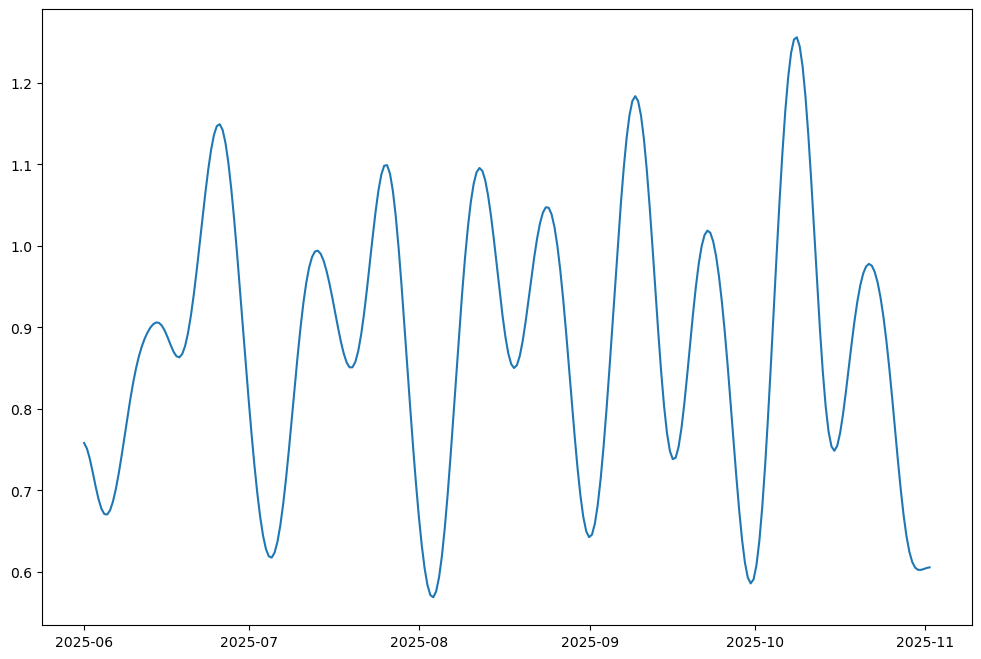

In [52]:
plt.figure(figsize=(12,8))
# diff = max_12h - min_12h
smooth = gaussian_filter1d(tides_smooth_df['wlo_range_12h'], sigma=3)
tides_smooth_df['wlo_smooth_range'] = smooth
plt.plot(tides_smooth_df['date'], smooth)
plt.show

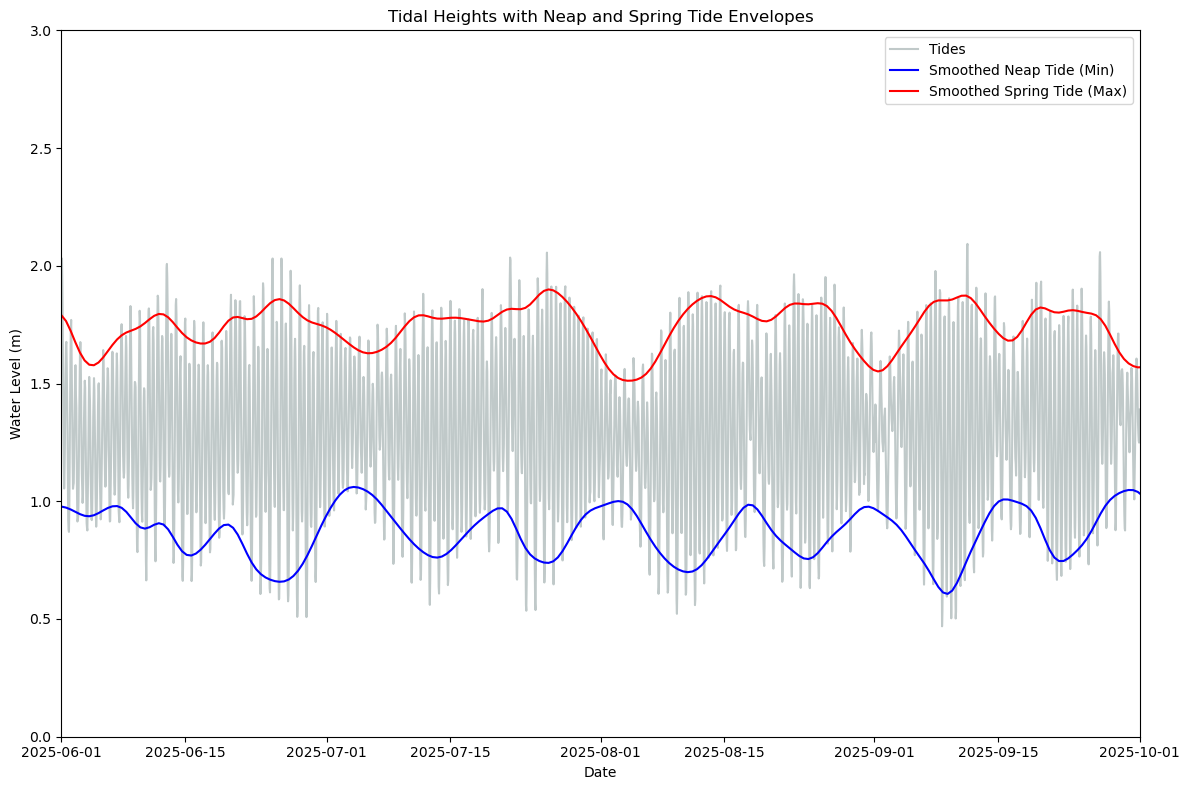

In [ ]:
# Plot neap spring tides from the nearest tidal station (pointe aux basques)
plt.figure(figsize=(12,8))
plt.plot(tides_df.index, tides_df['wlo_pab'], label='Tides: water level', color='darkslategrey', alpha=0.3)

# Plot smoothed min and max lines
plt.plot(tides_smooth_df['date'], tides_smooth_df['wlo_min_12h'], label='Smoothed Neap Tide (Min)', color='blue')
plt.plot(tides_smooth_df['date'], tides_smooth_df['wlo_max_12h'], label='Smoothed Spring Tide (Max)', color='red')

plt.xlim(pd.to_datetime('2025-06-01'),pd.to_datetime('2025-10-01'))
plt.ylim(0,3)

plt.xlabel('Date')
plt.ylabel('Water Level (m)')
plt.legend()
plt.tight_layout()
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

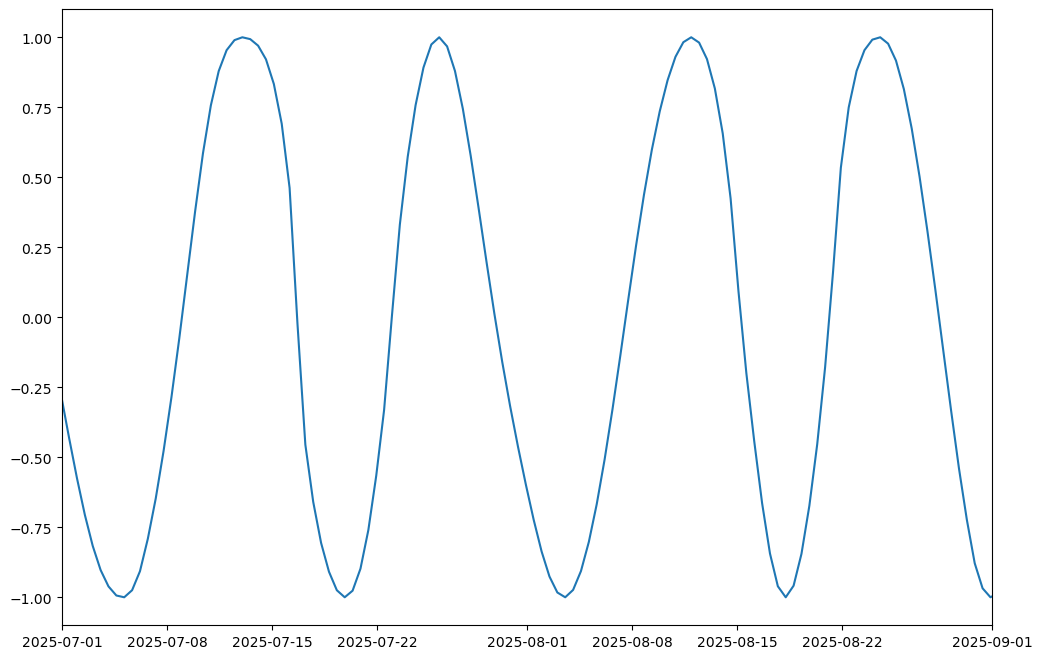

In [ ]:
# Normalized, cyclic function between neap-spring min max (c. two weeks cycle in the Gulf e.g. Bourgault et al. 2016)

window_size = 30 #
smooth_series = pd.Series(tides_smooth_df['wlo_range_12h'])

# Compute rolling min and max
rolling_min = smooth_series.rolling(window=window_size, center=True).min()
rolling_max = smooth_series.rolling(window=window_size, center=True).max()

# Normalize locally between -1 and 1
smooth_local_norm = ((smooth_series - rolling_min) / (rolling_max - rolling_min) - 0.5) * 2
tides_smooth_df['norm_range'] = smooth_local_norm

plt.figure(figsize=(12,8))
plt.xlim(pd.to_datetime('2025-07-01'),pd.to_datetime('2025-09-01'))
plt.plot(tides_smooth_df['date'], smooth_local_norm)
plt.show

In [ ]:
subset = tides_smooth_df[105:234]
subset

,date,wlo_min_12h,wlo_max_12h,wlo_range_12h,wlo_smooth_range,norm_range
105,2025-07-26 03:00:00+00:00,0.738207,1.899634,1.161427,1.099117,1.000000
106,2025-07-26 15:36:00+00:00,0.744782,1.895813,1.151030,1.088774,0.967448
107,2025-07-27 04:12:00+00:00,0.761586,1.884203,1.122618,1.067566,0.879528
108,2025-07-27 16:48:00+00:00,0.788144,1.867247,1.079102,1.036461,0.744446
109,2025-07-28 05:24:00+00:00,0.821449,1.846392,1.024942,0.997147,0.576322
...,...,...,...,...,...,...
229,2025-09-29 05:24:00+00:00,1.043180,1.604491,0.561312,0.611564,-0.899753
230,2025-09-29 18:00:00+00:00,1.047869,1.585527,0.537658,0.593038,-0.970516
231,2025-09-30 06:36:00+00:00,1.047313,1.574072,0.526758,0.585780,-1.000000
232,2025-09-30 19:12:00+00:00,1.039552,1.568642,0.529090,0.590682,-0.994128


### Check on seep triggers

In [ ]:
## Read buoy data from the weeks before seep start 
tides_before = pd.read_csv('data/tides/wlo_665_0309.csv')
tides_before['date'] = pd.to_datetime(tides_before['date'], format='%Y/%m/%d %H:%M')
tides_before.rename(columns={'water_level_m':'wlo_pab'},inplace=True)

tides_before = tides_before[2208:] # filter to jun 1st
tides_before

,date,wlo_pab
2208,2025-06-01 00:00:00,1.017
2209,2025-06-01 01:00:00,1.268
2210,2025-06-01 02:00:00,1.489
2211,2025-06-01 03:00:00,1.802
2212,2025-06-01 04:00:00,1.980
...,...,...
4433,2025-09-01 19:00:00,1.580
4434,2025-09-01 20:00:00,1.596
4435,2025-09-01 21:00:00,1.567
4436,2025-09-01 22:00:00,1.464


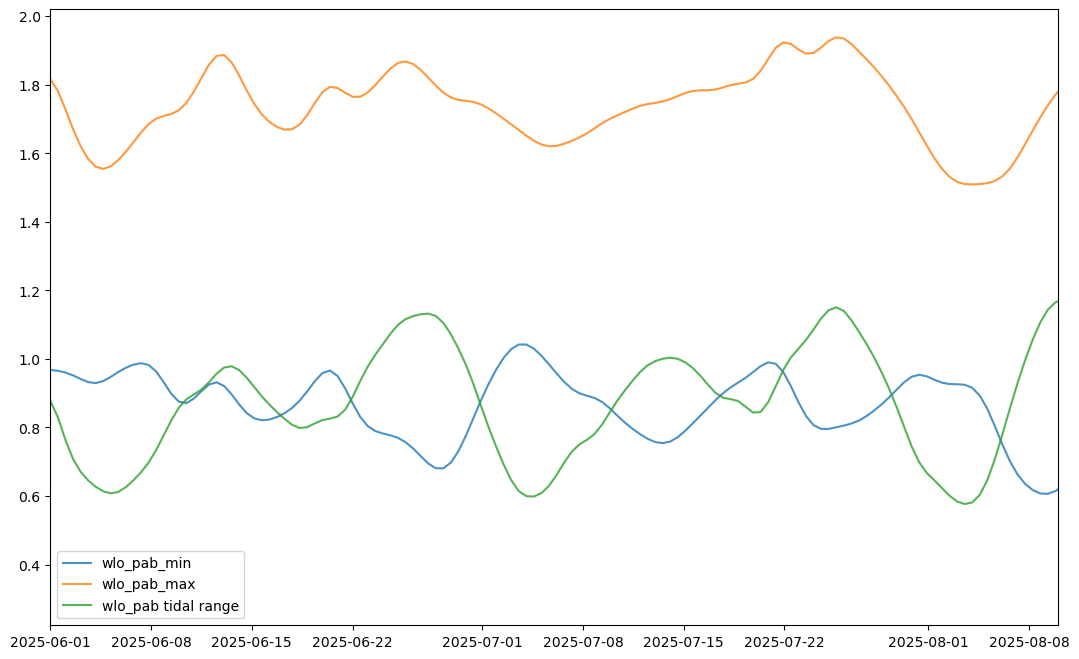

In [61]:
## Smooth the neap-spring tidal cycle

if 'date' in tides_before.columns:
    tides_before['date'] = pd.to_datetime(tides_before['date'], utc=True)
    tides_before.set_index('date', inplace=True)

    
tides_smooth_df2 = pd.DataFrame({})

plt.figure(figsize=(13,8))
for col in tides_before.columns:
    min_12h = tides_before[col].resample('12.6h').min() 
    max_12h = tides_before[col].resample('12.6h').max()
    range = max_12h - min_12h  # tidal range
    # Apply Gaussian smoothing
    smooth_min = gaussian_filter1d(min_12h.values, sigma=2)
    smooth_max = gaussian_filter1d(max_12h.values, sigma=2)
    smooth_range = gaussian_filter1d(range.values, sigma=1.6) # tidal range
    # Plot smoothed min and max lines
    plt.plot(min_12h.index, smooth_min,alpha=0.8,label=f'{col}_min')
    plt.plot(max_12h.index, smooth_max,alpha=0.8,label=f'{col}_max')
    plt.plot(max_12h.index, smooth_range,alpha=0.8,label=f'{col} tidal range')
    if not 'date' in tides_smooth_df2.columns:
        tides_smooth_df2['date'] = min_12h.index
    if col.startswith('wlo'):
        tides_smooth_df2['wlo_min_12h'] = smooth_min
        tides_smooth_df2['wlo_max_12h'] = smooth_max
        tides_smooth_df2['wlo_range_12h'] = smooth_range  
    

plt.xlim(pd.to_datetime('2025-06-01'),pd.to_datetime('2025-08-10'))

plt.legend()
plt.show()

In [62]:
df_airpress = pd.concat([df_0607,df[333:]], ignore_index=True)
df_airpress[4000:]

,date,Temp. de l'eau,Salinité,Pression,Densité,Fluorescence,Période de vague,Hauteur de vague moy.,Hauteur de vague max.,Vitesse du vent,...,Direction du vent,Temp. air,Humidité,Précipitation,CDOM,Courant - Vitesse (0m),Courant-Direction(0m),Eau - Rétrodiffusion,wind_speed_m_s,wind_speed_m_s_10m
4000,2025-08-24 02:30:00+00:00,17.27,31.15,101.509995,1022.50,0.3600,4.7,1.3,2.1,29.0,...,166.0,17.3,83.0,0.2,3.89,NaN,2.0,0.000458,8.055556,11.199762
4001,2025-08-24 03:00:00+00:00,17.29,31.15,101.509995,1022.50,0.3600,4.8,1.3,2.0,27.0,...,181.0,17.6,81.0,0.2,3.99,NaN,358.0,0.000422,7.500000,10.427365
4002,2025-08-24 03:30:00+00:00,17.27,31.16,101.509995,1022.51,0.3600,4.9,1.3,1.9,21.0,...,223.0,17.6,81.0,0.2,3.99,NaN,10.0,0.000435,5.833333,8.110173
4003,2025-08-24 04:00:00+00:00,17.26,31.16,101.520004,1022.51,0.3744,4.5,1.1,1.8,19.0,...,254.0,18.6,78.0,0.2,3.89,NaN,25.0,0.000422,5.277778,7.337775
4004,2025-08-24 04:30:00+00:00,17.28,31.16,101.520004,1022.51,0.3672,4.6,1.2,2.0,24.0,...,261.0,18.6,78.0,0.3,3.99,NaN,40.0,0.000435,6.666667,9.268769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5590,2025-09-26 17:30:00+00:00,14.56,31.11,99.580000,1023.07,NaN,5.5,2.6,4.0,36.0,...,284.0,15.4,86.0,36.3,NaN,NaN,94.0,NaN,10.000000,13.903153
5591,2025-09-26 18:00:00+00:00,14.55,31.11,99.659996,1023.07,NaN,5.2,2.3,3.9,37.0,...,292.0,15.1,83.0,36.3,NaN,NaN,102.0,NaN,10.277778,14.289352
5592,2025-09-26 18:30:00+00:00,14.59,31.12,99.670000,1023.07,NaN,5.6,2.3,4.0,41.0,...,300.0,14.9,83.0,36.3,NaN,NaN,106.0,NaN,11.388889,15.834146
5593,2025-09-26 19:00:00+00:00,14.64,31.12,99.720000,1023.07,NaN,5.1,2.3,3.5,39.0,...,298.0,14.5,83.0,36.3,NaN,NaN,115.0,NaN,10.833333,15.061749


### Make fig 3

C:\Users\juvad3723\AppData\Local\Temp\ipykernel_65232\4010201916.py:161: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(ncol=4, fontsize=9, loc='upper right')


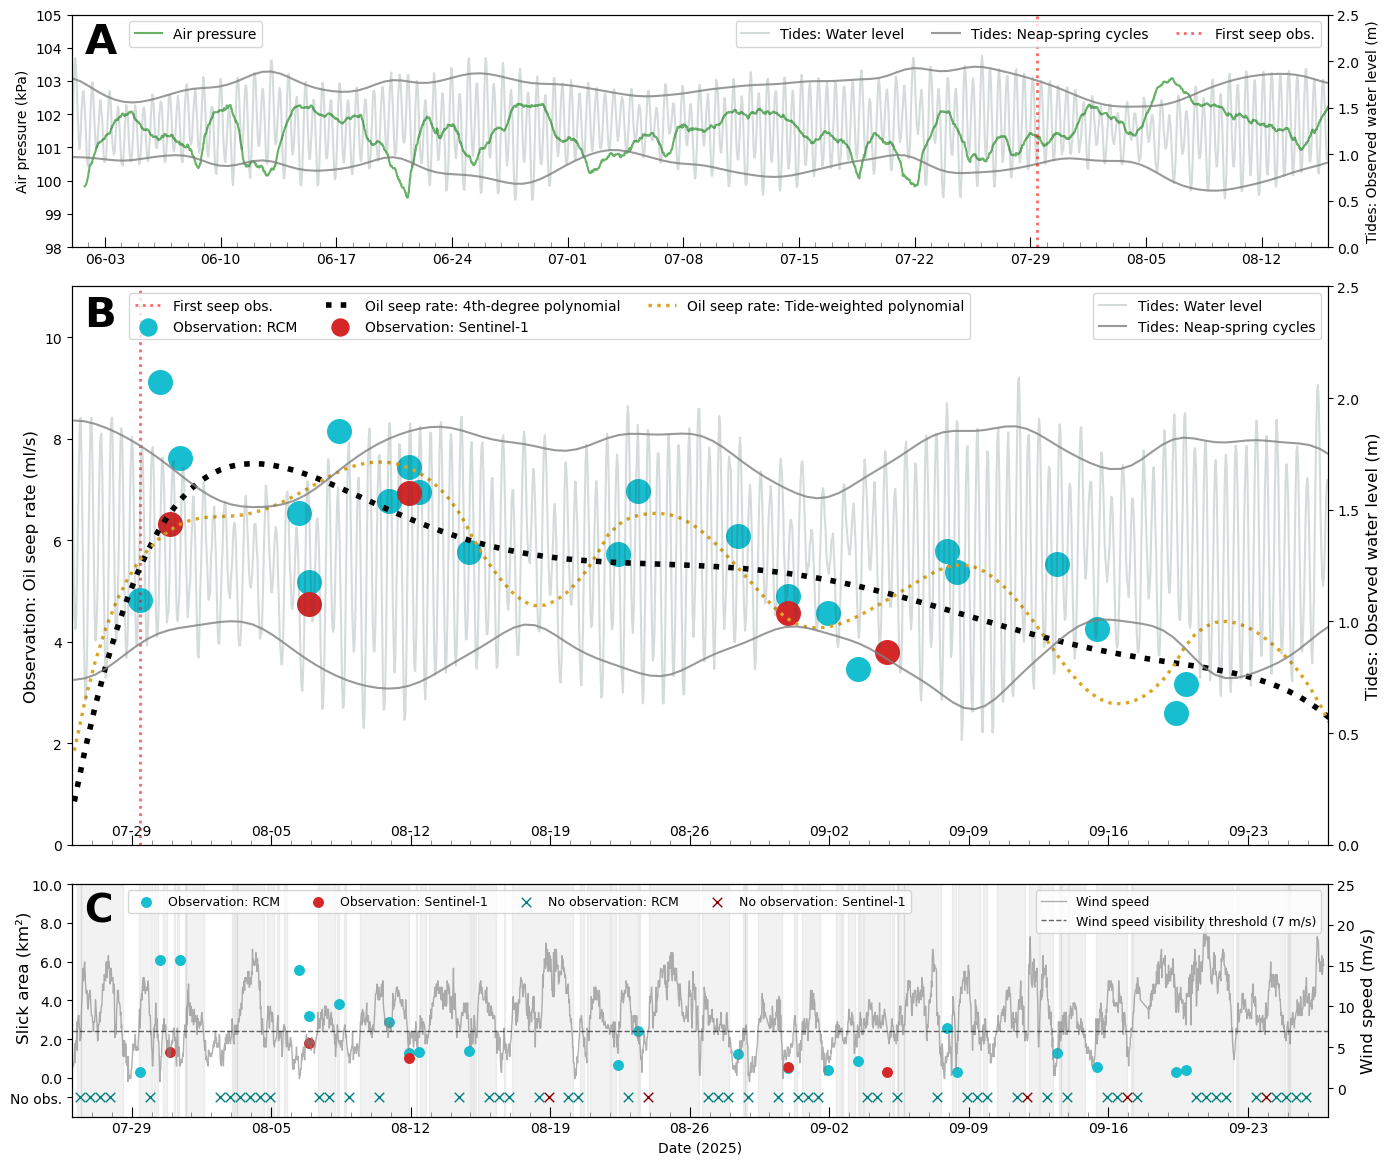

In [ ]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

#_____________________________________________________________________________________________________________________________

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False, gridspec_kw={'height_ratios': [1, 2.4, 1]})
# set x-axis limits for both subplots
xmin = pd.to_datetime('2025-07-26')
xmax = pd.to_datetime('2025-09-27')


# set x min / xmax for all 3 subplots
for ax in axes:
    ax.set_xlim([xmin, xmax])
    if ax == axes[0]:
        ax.set_xlim([pd.to_datetime('2025-06-01'), pd.to_datetime('2025-08-16')])

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # major ticks every week
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d')) # use MM-DD format instead of YYYY-MM-DD

    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())  # hide minor tick labels
    # Make minor ticks visible
    ax.tick_params(axis='x', direction='in', which='major', length=7)
    ax.tick_params(axis='x', direction='in', which='minor', length=3.5, color='gray')



#_SUB plot 1_________________________________________________________________

axes[0].plot(df_airpress['date'],df_airpress['Pression'], color='green',alpha=0.6, label='Air pressure')
# axes[0].xlabel('Date')
axes[0].set_ylim(98,105)
axes[0].set_ylabel('Air pressure (kPa)')

ax0 = axes[0].twinx()
ax0.plot(tides_before.index, tides_before['wlo_pab'], label='Tides: Water level', color='darkslategrey',alpha=0.2)
ax0.plot(tides_smooth_df2['date'],tides_smooth_df2['wlo_min_12h'], color='grey',alpha=0.8,label='Tides: Neap-spring cycles')
ax0.plot(tides_smooth_df2['date'],tides_smooth_df2['wlo_max_12h'], color='grey',alpha=0.8)
ax0.set_ylim(0,2.5)
ax0.set_ylabel('Tides: Observed water level (m)', fontsize=10)

# seep start line
first_obs_datetime = pd.to_datetime('2025-07-29 10:00:00')
ax0.axvline(x=first_obs_datetime , color='red', linestyle=':', linewidth=2, alpha=0.6, label='First seep obs.')


axes[0].legend(bbox_to_anchor=(0.04, 1),loc='upper left')
ax0.legend(loc='upper right', ncol=3)

#_SUB plot 2_________________________________________________________________
ax1 = axes[1].twinx()

ax1.plot(tides_df.index, tides_df['wlo_pab'], label='Tides: Water level', color='darkslategrey',alpha=0.2)
ax1.plot(subset['date'], subset['wlo_min_12h'], color='grey',alpha=0.8,label='Tides: Neap-spring cycles')
ax1.plot(subset['date'], subset['wlo_max_12h'], color='grey',alpha=0.8)
ax1.set_ylim(0,2.5)
ax1.set_ylabel('Tides: Observed water level (m)', fontsize=12)

# ax1.set_ylabel('Daily tidal range (m)', fontsize=12)

ax1.legend()

axes[1].axvline(x=first_obs_datetime, color='red', linestyle=':', linewidth=2, alpha=0.6, label='First seep obs.')

# RCM points
axes[1].scatter(
    gdf.loc[gdf['sensor'] == 'RCM', 'img_datetime'],
    gdf.loc[gdf['sensor'] == 'RCM', 'rate_ml/s'],
    color='tab:cyan',
    label='Observation: RCM',
    marker='o',
    edgecolors='tab:cyan', 
    # facecolors='white',
    linewidths=2,
    s=256
)

# polynomial function
filtered_gdf = gdf[gdf['a1'] == 1].copy()

# NEed to define synthetic start and end because no observations at y=0 (seep start and end)
synthetic_start = pd.to_datetime('2025-07-26 03:00:00', utc=True)
synthetic_end = pd.to_datetime('2025-10-01 07:48:00', utc=True)

synthetic_numeric = synthetic_start.value / 1e9  

# Convert datetimes to hours after synthetic start
filtered_gdf['hours_after_start'] = (
    (pd.to_datetime(filtered_gdf['img_datetime']) - synthetic_start)
    .dt.total_seconds() / 3600
)

# Ensure numeric values for y
filtered_gdf['rate_ml/s'] = pd.to_numeric(filtered_gdf['rate_ml/s'], errors='coerce')

# Drop NaNs
filtered_gdf = filtered_gdf.dropna(subset=['hours_after_start', 'rate_ml/s'])

# Prepare arrays
x = filtered_gdf['hours_after_start'].astype(float).values
y = filtered_gdf['rate_ml/s'].astype(float).values

# Add synthetic start (0 h) and end (hours after synthetic start)
synthetic_end_hours = (synthetic_end - synthetic_start).total_seconds() / 3600

x_extended = np.concatenate(([0.0], x, [synthetic_end_hours]))
y_extended = np.concatenate(([0.0], y, [0.0]))

# Fit polynomial
coeffs = np.polyfit(x_extended, y_extended, deg=6)
poly_func = np.poly1d(coeffs)


# Generate smooth curve across full range
x_fit = np.linspace(0, synthetic_end_hours, 129)
x_fit_datetime = synthetic_start + pd.to_timedelta(x_fit, unit='h')
y_fit = poly_func(x_fit)

axes[1].plot(
    x_fit_datetime, y_fit,
    color='black', linestyle=':', linewidth=4,
    label='Oil seep rate: 4th-degree polynomial'
)

axes[1].scatter(
    gdf.loc[gdf['sensor'] == 'S1', 'img_datetime'],
    gdf.loc[gdf['sensor'] == 'S1', 'rate_ml/s'],
    color='tab:red',
    label='Observation: Sentinel-1',
    marker='o',
    edgecolors='tab:red', 
    linewidths=2,
    s=256
)

# x axis date ticks
axes[1].xaxis.set_minor_locator(mdates.DayLocator(interval=1))
axes[1].xaxis.set_minor_formatter(mticker.NullFormatter())  

# Make minor ticks visible
axes[1].tick_params(axis='x', direction='in', which='major', length=7)
axes[1].tick_params(axis='x', direction='in', which='minor', length=3.5, color='gray')

# weighted_poly = y_fit + smooth_local_norm
weighted_poly = y_fit + subset['norm_range']
axes[1].plot(
    x_fit_datetime,weighted_poly,
    color='goldenrod', linestyle=':', linewidth=2.6,
    label='Oil seep rate: Tide-weighted polynomial'
)

maxy = round(filtered_gdf['rate_ml/s'].max()+2)

# Set y-limits 
axes[1].set_ylim(0,maxy)
axes[1].set_ylabel('Observation: Oil seep rate (ml/s)', fontsize=12)
axes[1].legend()



#_SUB plot 3_________________________________________________________________

ax2 = axes[2].twinx()
ax2.legend(ncol=4, fontsize=9, loc='upper right')
# subplot 2
ax2.plot(
    df['date'],
    df['wind_speed_m_s_10m'],
    color='gray',
    linewidth=1,
    label='Wind speed',
    alpha=0.62
)

# plot wind threshold horizontal line
ax2.plot(
    [xmin, xmax],
    [7, 7],
    color='black',
    linewidth=1,
    linestyle='--',
    alpha=0.6,
    label='Wind speed visibility threshold (7 m/s)')


for start_d, end_d in ll:
    axes[2].axvspan(start_d, end_d, alpha=0.1, zorder=-1, color='gray')

ax2.set_ylabel('Wind speed (m/s)', fontsize=12)
ax2.set_ylim(-3.5,24)

# remove negative ticks
yticks = list(ax2.get_yticks())
yticks = [t for t in yticks if t >= 0]
ax2.set_yticks(yticks)

ax2.legend(loc='upper right', fontsize=9)


sz = 47 # set scatter plot point size

# set axis range to allow space below zero
axes[2].set_ylim(-2, 10)
axes[2].set_ylabel('Slick area (km²)', fontsize=12, labelpad=-10, rotation=90, verticalalignment='center', y=0.6)

# add a custom tick for 'No obs.'
yticks = list(axes[2].get_yticks())

# keep only ticks >= 0
yticks = [t for t in yticks if t >= 0]
axes[2].set_yticks([-1] + yticks)
axes[2].set_yticklabels(['No obs.'] + [str(t) for t in yticks])

axes[2].scatter(
    gdf.loc[(gdf['sensor'] == 'RCM') & (gdf['a1'] == 1), 'img_datetime'],
    gdf.loc[(gdf['sensor'] == 'RCM') & (gdf['a1'] == 1), 'area_km2'],
    color='tab:cyan',
    label='Observation: RCM',
    marker='o',
    linewidths=1,
    alpha=1,
    s=sz
)

axes[2].scatter(
    gdf.loc[(gdf['sensor'] == 'S1') & (gdf['a1'] == 1), 'img_datetime'],
    gdf.loc[(gdf['sensor'] == 'S1') & (gdf['a1'] == 1), 'area_km2'],
    color='tab:red',
    label='Observation: Sentinel-1',
    marker='o',
    linewidths=1,
    alpha=1,
    s=sz
)

axes[2].scatter(
    gdf.loc[(gdf['sensor']=='RCM') & (gdf['a1']!=1), 'img_datetime'],
    [-1] * gdf.loc[(gdf['sensor']=='RCM') & (gdf['a1']!=1)].shape[0],
    color='teal',
    label='No observation: RCM',
    marker='x',
    linewidths=1,
    s=sz
)

axes[2].scatter(
    gdf.loc[(gdf['sensor']=='S1') & (gdf['a1']!=1), 'img_datetime'],
    [-1] * gdf.loc[(gdf['sensor']=='S1') & (gdf['a1']!=1)].shape[0],
    color='darkred',
    label='No observation: Sentinel-1',
    marker='x',
    linewidths=1,
    s=sz
)

# tidal twin axis legend
ax1.legend(ncol=1, loc='upper right', fontsize=10)

# # main top subplot legend
axes[1].legend(ncol=3, loc='upper left',bbox_to_anchor=(0.04, 1), fontsize=10, markerscale=0.7)

# keep x-axis at bottom but move labels inside
axes[1].xaxis.set_label_position('bottom')  # label at bottom
axes[1].tick_params(axis='x', labelbottom=True, direction='in', pad=-15)


# bottom subplot legend
axes[2].set_xlabel('Date (2025)')
axes[2].legend(ncol=4, fontsize=9,bbox_to_anchor=(0.04, 1), loc='upper left')
pos = axes[2].get_position()  # get current position [left, bottom, width, height]
axes[2].set_position([pos.x0, pos.y0 - 0.02, pos.width, pos.height]) # move down 0.05

# add subplot labels (a/b)
axes[0].text(0.01, 0.967, 'A', transform=axes[0].transAxes,
             fontsize=30, fontweight='bold', va='top', ha='left')
axes[1].text(0.01, 0.985, 'B', transform=axes[1].transAxes,
             fontsize=30, fontweight='bold', va='top', ha='left')

axes[2].text(0.01, 0.967, 'C', transform=axes[2].transAxes,
             fontsize=28, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.savefig('latex/figs/figure_f1-3.png', bbox_inches='tight', dpi=500)
plt.show()


In [ ]:
# print max seep rate (peak)
filtered_gdf['rate_ml/s'].max()

## Calculate total emissions

In [ ]:

# Find roots of the polynomial
roots = np.roots(coeffs)
# Keep real roots within the range
real_roots = sorted([r.real for r in roots if np.isreal(r) and 0 <= r.real <= synthetic_end_hours])

if len(real_roots) >= 2:
    start_root = real_roots[0]
    end_root = real_roots[-1]
else:
    # Fallback: use full range
    start_root = 0
    end_root = synthetic_end_hours

# Integrate polynomial
poly_integral = poly_func.integ()
area_hours = poly_integral(end_root) - poly_integral(start_root)

# Convert to ml (since y is ml/s and x is hours)
area_ml = area_hours * 3600  # seconds per hour
area_l = area_ml / 1000
print(f"Total volume emitted: {area_ml:.2f} ml")
print('volume emitted in liters:', round(area_l),'L')

Total volume emitted: 28608942.78 ml
volume emitted in liters: 28609 L


## fig f2

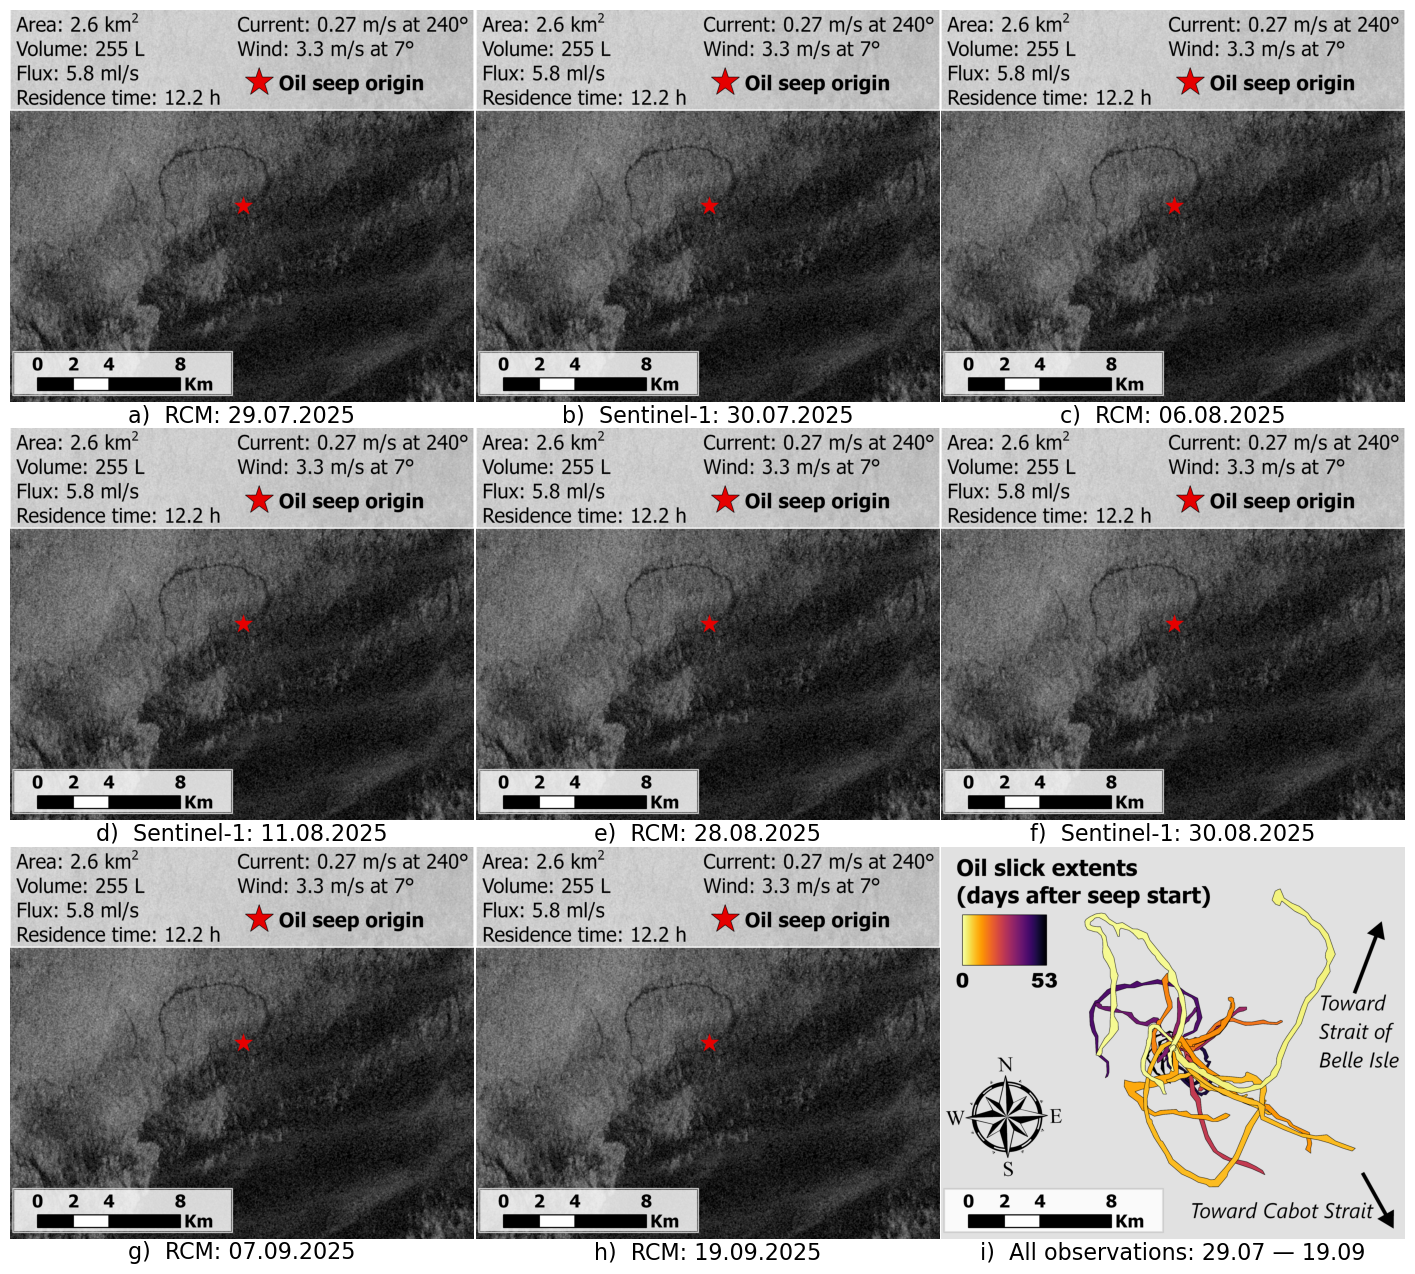

In [56]:
import os 
# if not os.getcwd('episodic_seep_gostl_suppmat'):
#     os.chdir('..')
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from glob import glob

# list_imgs = ['data/sar_samples/07_29_xwide.png' ]* 9
# list_captions = ['RCM: 29.07.2025' ]* 9
# list_imgs = [i for i in glob('data/sar_samples' + '/*.png') if 'wide' in i]
list_imgs = [r'c:\Users\juvad3723\.1\--Projects\Local\old_harry_paper\data\sar_samples\09_07.png'] * 8
list_imgs.append(r'c:\Users\juvad3723\.1\--Projects\Local\old_harry_paper\data\sar_samples\all__.png')
list_captions = [
    'a)  RCM: 29.07.2025', 
    'b)  Sentinel-1: 30.07.2025', 
    'c)  RCM: 06.08.2025', 
    'd)  Sentinel-1: 11.08.2025', 
    'e)  RCM: 28.08.2025', 
    'f)  Sentinel-1: 30.08.2025', 
    'g)  RCM: 07.09.2025',
    'h)  RCM: 19.09.2025', 
    'i)  All observations: 29.07 — 19.09']

# Create a 3x3 grid of subplots
fig, axes = plt.subplots(
    3, 3, figsize=(18, 16),
    gridspec_kw={'wspace': 0.004, 'hspace': 0.06}  # adjust space between subfigs
)

# Flatten axes array for easy iteration
axes = axes.ravel()

# Loop through the images and captions
for i, (img_path, caption) in enumerate(zip(list_imgs, list_captions)):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis("off")

    # Add caption centered below each image
    axes[i].text(
        0.5, -0.005, caption,
        ha='center', va='top',
        transform=axes[i].transAxes,
        fontsize=16
    )

plt.savefig(r'c:\Users\juvad3723\.1\--Projects\Local\old_harry_paper\latex\figs\figure_f2-2.png',bbox_inches='tight',dpi=350)
# Show the plot
plt.show()


# in-text stats

## wind speed visibility

In [ ]:
# Reset index to make datetime a column
df_current_reset = df_current.reset_index().rename(columns={'date':'img_datetime'})

# Merge on img_datetime
gdf2 = gdf.merge(
    df_current_reset[['img_datetime', 'wind_spd_m_s_10m']],
    on='img_datetime',
    how='left'  # or 'inner' depending on your needs
)

subset_gdf = gdf2[gdf2['img_datetime']>pd.to_datetime('2025-07-29', utc=True)]
subset_gdf = subset_gdf[subset_gdf['img_datetime']<pd.to_datetime('2025-09-30', utc=True)]

print('mean wind 1:',subset_gdf[subset_gdf['a1']==1]['avg_wind_spd_m_s'].mean())
print('mean wind 0:',subset_gdf[subset_gdf['a1']==0]['avg_wind_spd_m_s'].mean())

# # Reset index to make datetime a column
# df_current_reset = df_current.reset_index().rename(columns={'date':'img_datetime'})

# # Merge on img_datetime
# subset_gdf = subset_gdf.merge(
#     df_current_reset[['img_datetime', 'wind_spd_m_s_10m']],
#     on='img_datetime',
#     how='left'  # or 'inner' depending on your needs
# )

subset_gdf.isna().sum()
subset_gdf = subset_gdf.drop_duplicates('img_id')

print('mean wind 1:',subset_gdf[subset_gdf['a1']==1]['wind_spd_m_s_10m'].mean())
print('mean wind 0:',subset_gdf[subset_gdf['a1']==0]['wind_spd_m_s_10m'].mean())

obs_subset = subset_gdf[subset_gdf['a1']==1]

mean wind 1: 6.259127803226439
mean wind 0: 8.914753144510135
mean wind 1: 5.481050669798789
mean wind 0: 8.926290526823715


In [ ]:
df_current_reset[1970:1980]

,img_datetime,Unnamed: 0,Temp. de l'eau,Salinité,Pression,Densité,Période de vague,Hauteur de vague moy.,Hauteur de vague max.,Vitesse du vent,Rafales,Direction du vent,Temp. air,Humidité,Courant-Direction(0m),current_spd_m_s,wind_spd_m_s,wind_spd_m_s_10m,V_s,meurer_vs
1970,2025-09-04 16:30:00+00:00,1970,17.69,30.86,101.320000,1022.18,4.2,0.9,1.4,23.0,32.0,226.0,18.4,85.0,74.0,0.217612,6.388889,8.882570,0.252168,0.385321
1971,2025-09-04 17:00:00+00:00,1971,17.75,30.87,101.320000,1022.17,3.9,0.8,1.2,20.0,30.0,230.0,18.4,85.0,72.0,0.225298,5.555556,7.723974,0.259399,0.371132
1972,2025-09-04 17:04:53+00:00,1972,17.74,30.86,101.320000,1022.17,3.9,0.8,1.2,21.0,27.0,235.0,18.5,84.0,66.0,0.232136,5.833333,8.110173,0.266237,0.385261
1973,2025-09-04 17:30:00+00:00,1973,17.76,30.87,101.320000,1022.17,3.9,0.8,1.6,22.0,32.0,231.0,18.5,84.0,49.0,0.227586,6.111111,8.496371,0.261687,0.388003
1974,2025-09-04 18:00:00+00:00,1974,17.81,30.87,101.320000,1022.16,4.0,0.9,1.7,24.0,35.0,244.0,18.6,84.0,44.0,0.234726,6.666667,9.268769,0.274729,0.409726
1975,2025-09-04 18:30:00+00:00,1975,17.83,30.87,101.320000,1022.15,4.0,1.0,1.7,25.0,35.0,247.0,18.6,84.0,52.0,0.231737,6.944444,9.654967,0.281123,0.414029
1976,2025-09-05 00:00:00+00:00,1976,18.22,30.91,101.520004,1022.10,4.3,0.9,1.2,14.0,19.0,230.0,18.3,87.0,81.0,0.215615,3.888889,5.406782,0.247815,0.317698
1977,2025-09-05 00:30:00+00:00,1977,18.20,30.90,101.520004,1022.09,4.6,0.9,1.4,15.0,21.0,221.0,18.3,84.0,76.0,0.219872,4.166667,5.792980,0.246174,0.329247
1978,2025-09-05 01:00:00+00:00,1978,18.19,30.89,101.520004,1022.09,4.1,0.8,1.1,17.0,23.0,221.0,18.3,84.0,73.0,0.231287,4.722222,6.565378,0.260637,0.355245
1979,2025-09-05 01:30:00+00:00,1979,18.16,30.89,101.550000,1022.09,4.3,0.7,1.2,18.0,24.0,212.0,18.3,86.0,68.0,0.227732,5.000000,6.951576,0.247212,0.358982


In [ ]:
subset_gdf.loc[16, 'wind_spd_m_s_10m'] = (9.654967 + 5.406782) / 2  ## Take the average between obs at 18:30 and 00:00 to fill NaN
subset_gdf.loc[16]
subset_gdf.reset_index(inplace=True)

In [ ]:
27/76

0.35526315789473684

In [ ]:
print('% obs above 7ms: ',subset_gdf[subset_gdf['wind_spd_m_s_10m']>7]['a1'].sum() / len(subset_gdf[subset_gdf['wind_spd_m_s_10m']>7]))
print('% obs below 7ms: ',subset_gdf[subset_gdf['wind_spd_m_s_10m']<7]['a1'].sum() / len(subset_gdf[subset_gdf['wind_spd_m_s_10m']<7]))

% obs above 7ms:  0.17073170731707318
% obs below 7ms:  0.5882352941176471


In [ ]:
subset_gdf[subset_gdf['wind_spd_m_s_10m']>7]['a1'].sum()

np.int64(6)

In [ ]:
gdf['wind_spd_m_s_10m'].isna().sum()

np.int64(2)

In [ ]:
gdf['a1'].sum()

np.int64(27)

In [ ]:
27/85

0.3176470588235294